# Phân tích Khám phá Dữ liệu (EDA) - Tập dữ liệu MovieLens Small

Notebook này thực hiện quá trình **Exploratory Data Analysis (EDA)** trên tập dữ liệu **MovieLens Small** (`ml-latest-small`). Mục tiêu là khai phá dữ liệu để tìm ra các xu hướng, hành vi đánh giá của người dùng và đặc điểm của các bộ phim. Những phân tích này là cơ sở quan trọng trước khi thiết kế và xây dựng các mô hình gợi ý phim (Recommendation Systems).

### Mục tiêu phân tích:
1. **Tổng quan về dữ liệu**: Cấu trúc, kích thước, các trường thông tin và kiểm tra dữ liệu khuyết thiếu.
2. **Hành vi đánh giá (Ratings)**: Phân bố điểm đánh giá, phân bố số lượng đánh giá theo người dùng và theo phim. Mối quan hệ giữa chất lượng trung bình và mức độ phổ biến.
3. **Phim & Thể loại (Movies & Genres)**: Trích xuất năm phát hành, xu hướng sản xuất phim qua các năm, phân bố thể loại phim, điểm trung bình theo thể loại.
4. **Thẻ gắn (Tags)**: Khám phá các từ khóa gắn thẻ phổ biến từ người dùng.
5. **Xu hướng theo thời gian (Temporal Analysis)**: Sự thay đổi về số lượng tương tác và điểm đánh giá qua các năm.
6. **Tổng kết**: Đưa ra nhận định và các bước tiếp theo để phát triển Recommendation System.

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

# Configure visualization styles
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

print("Libraries loaded successfully!")

Libraries loaded successfully!


## Phần 1: Tải Dữ liệu và Tổng quan Cấu trúc

Chúng ta sẽ đọc 4 file dữ liệu chính từ thư mục `data/ml-latest-small/`:
- `movies.csv`: Chứa thông tin về phim bao gồm mã phim, tiêu đề và các thể loại.
- `ratings.csv`: Chứa thông tin đánh giá điểm số của người dùng cho các bộ phim.
- `tags.csv`: Chứa các từ khóa gắn thẻ (tags) do người dùng gắn cho phim.
- `links.csv`: Chứa các liên kết ID sang IMDb và TMDb để kết nối dữ liệu mở rộng.

In [2]:
# Path to the data directory
data_dir = os.path.join("data", "ml-latest-small")

# Read CSV files
movies = pd.read_csv(os.path.join(data_dir, "movies.csv"))
ratings = pd.read_csv(os.path.join(data_dir, "ratings.csv"))
tags = pd.read_csv(os.path.join(data_dir, "tags.csv"))
links = pd.read_csv(os.path.join(data_dir, "links.csv"))

print("Data loaded successfully!")
print(f"- Number of movies: {len(movies):,}")
print(f"- Number of ratings: {len(ratings):,}")
print(f"- Number of tags: {len(tags):,}")
print(f"- Number of links: {len(links):,}")

Data loaded successfully!
- Number of movies: 9,742
- Number of ratings: 100,836
- Number of tags: 3,683
- Number of links: 9,742


Hãy cùng xem qua vài dòng dữ liệu đầu tiên của mỗi bảng để hiểu rõ hơn về các trường thông tin.

In [3]:
print("--- Sample movies data ---")
display(movies.head(3))

print("\n--- Sample ratings data ---")
display(ratings.head(3))

print("\n--- Sample tags data ---")
display(tags.head(3))

print("\n--- Sample links data ---")
display(links.head(3))

--- Sample movies data ---


,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance



--- Sample ratings data ---


,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224



--- Sample tags data ---


,userId,movieId,tag,timestamp
0,2,60756,funny,1445714994
1,2,60756,Highly quotable,1445714996
2,2,60756,will ferrell,1445714992



--- Sample links data ---


,movieId,imdbId,tmdbId
0,1,114709,862.0
1,2,113497,8844.0
2,3,113228,15602.0


### Kiểm tra giá trị khuyết thiếu và kiểu dữ liệu

Chúng ta cần kiểm tra xem có giá trị bị thiếu (`null`/`NaN`) trong các bảng hay không, và kiểm tra kiểu dữ liệu của các cột để chuẩn bị cho việc phân tích và tiền xử lý.

In [4]:
for df_name, df in zip(['movies', 'ratings', 'tags', 'links'], [movies, ratings, tags, links]):
    print(f"\n===== Info of {df_name} table =====")
    df.info()
    null_counts = df.isnull().sum()
    if null_counts.sum() > 0:
        print("\nColumns with missing values:")
        print(null_counts[null_counts > 0])
    else:
        print("\nNo missing values found!")


===== Info of movies table =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9742 entries, 0 to 9741
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   movieId  9742 non-null   int64 
 1   title    9742 non-null   object
 2   genres   9742 non-null   object
dtypes: int64(1), object(2)
memory usage: 228.5+ KB

No missing values found!

===== Info of ratings table =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100836 entries, 0 to 100835
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   userId     100836 non-null  int64  
 1   movieId    100836 non-null  int64  
 2   rating     100836 non-null  float64
 3   timestamp  100836 non-null  int64  
dtypes: float64(1), int64(3)
memory usage: 3.1 MB

No missing values found!

===== Info of tags table =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3683 entries, 0 to 3682
Data columns (total 4 co

## Phần 2: Khai phá Dữ liệu Ratings (Bảng xếp hạng phim)

Bảng `ratings` chứa thông tin hành vi cốt lõi của người dùng. Mỗi dòng biểu thị một lần người dùng đánh giá một bộ phim với thang điểm từ 0.5 đến 5.0 (bước nhảy là 0.5).

Chúng ta sẽ phân tích:
1. Thống kê mô tả chung về điểm đánh giá.
2. Phân bố điểm số ratings.
3. Số lượng ratings của mỗi người dùng (hành vi của người dùng).
4. Số lượng ratings của mỗi bộ phim (mức độ phổ biến của phim).
5. Mối quan hệ giữa điểm đánh giá trung bình và số lượng ratings của phim.

In [5]:
print("Descriptive statistics for ratings:")
display(ratings['rating'].describe())

Descriptive statistics for ratings:


count    100836.000000
mean          3.501557
std           1.042529
min           0.500000
25%           3.000000
50%           3.500000
75%           4.000000
max           5.000000
Name: rating, dtype: float64

### 2.1 Phân bố điểm số ratings

Chúng ta vẽ biểu đồ phân bố tần suất xuất hiện của từng thang điểm từ 0.5 đến 5.0.

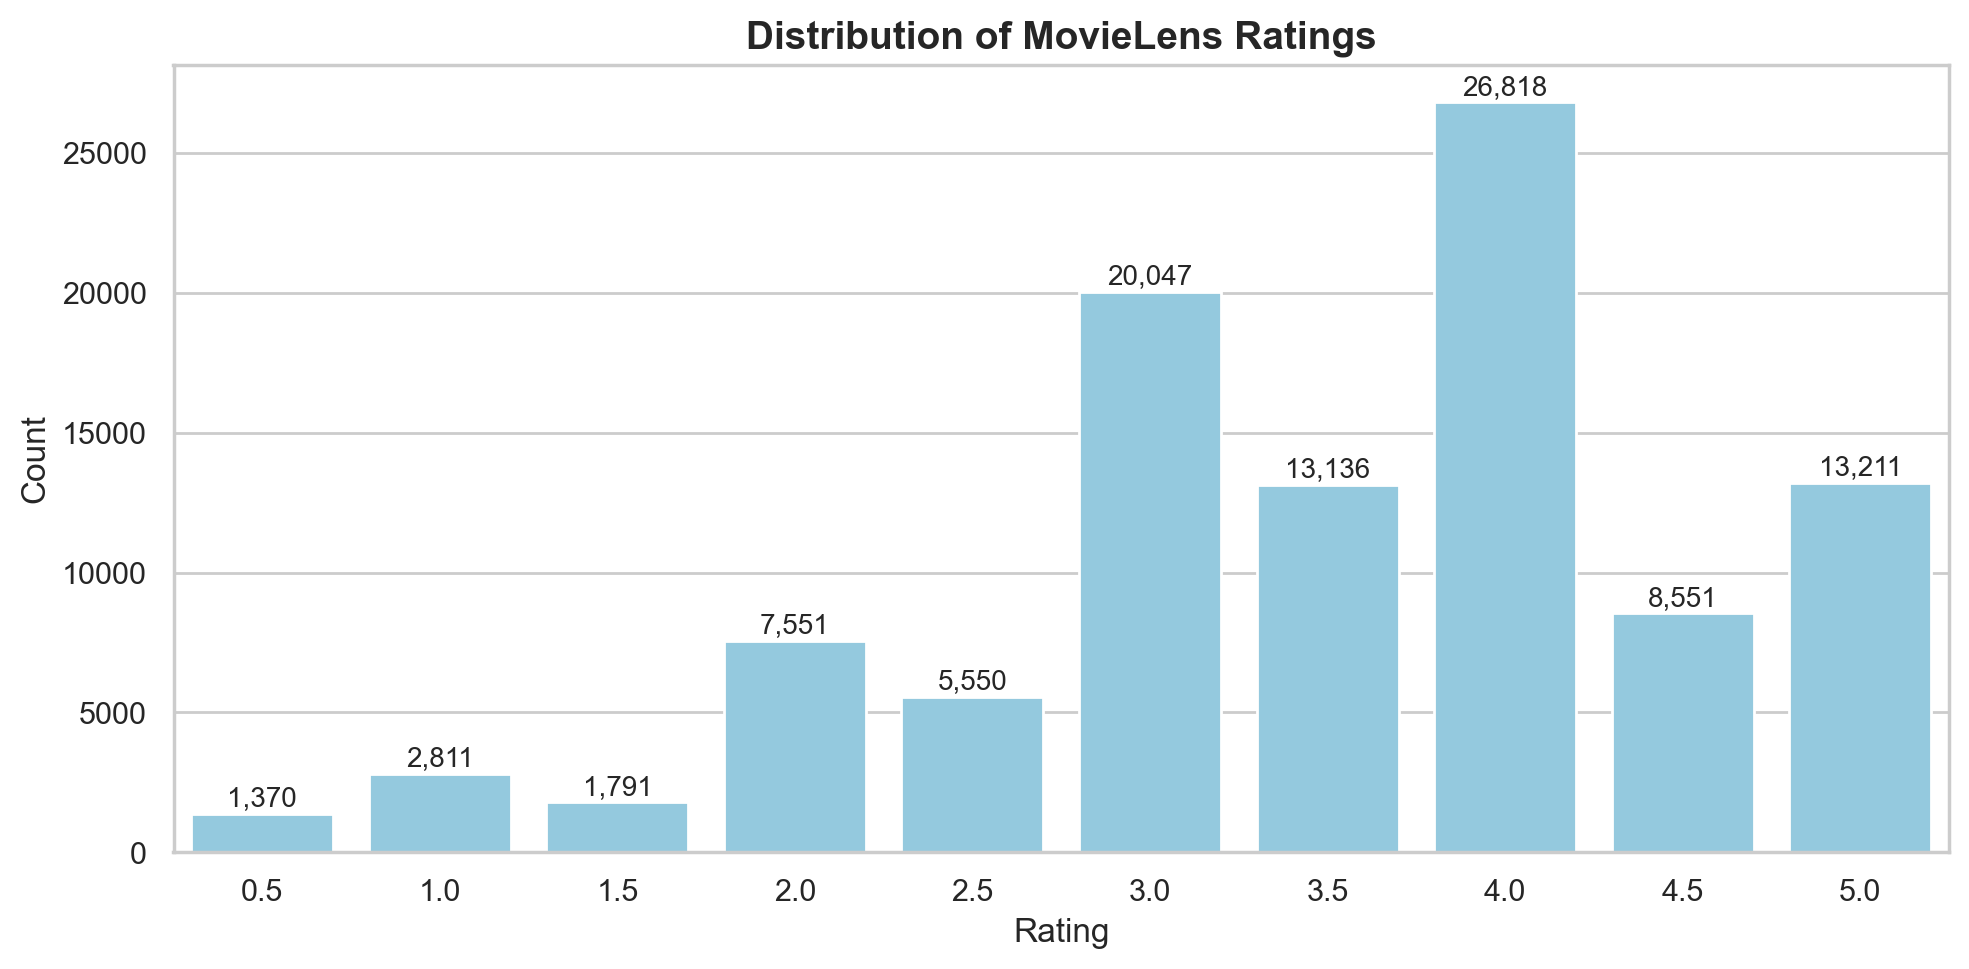

In [6]:
plt.figure(figsize=(10, 5))
ax = sns.countplot(x='rating', data=ratings, color='skyblue')
plt.title('Distribution of MovieLens Ratings', fontsize=14, fontweight='bold')
plt.xlabel('Rating', fontsize=12)
plt.ylabel('Count', fontsize=12)

# Add frequency numbers on top of each bar
for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points', fontsize=10)

plt.tight_layout()
plt.show()

**Nhận xét:**
- Điểm đánh giá phổ biến nhất là **4.0** (với hơn 26,800 lượt đánh giá), tiếp theo là **3.0** và **5.0**.
- Người dùng có xu hướng đánh giá các điểm số nguyên (1.0, 2.0, 3.0, 4.0, 5.0) nhiều hơn rõ rệt so với các điểm số lẻ (0.5, 1.5, 2.5, 3.5, 4.5).
- Phân bố điểm số bị lệch trái (skewed to the left), cho thấy người dùng có xu hướng đánh giá phim tích cực hơn (điểm trung bình khoảng 3.5 sao).

### 2.2 Phân tích ratings theo người dùng (User activity)

Chúng ta sẽ đếm số lượng phim mỗi người dùng đã đánh giá để xem thói quen hoạt động của người dùng trong hệ thống.

Descriptive statistics for ratings per user:
count     610.000000
mean      165.304918
std       269.480584
min        20.000000
25%        35.000000
50%        70.500000
75%       168.000000
max      2698.000000
dtype: float64


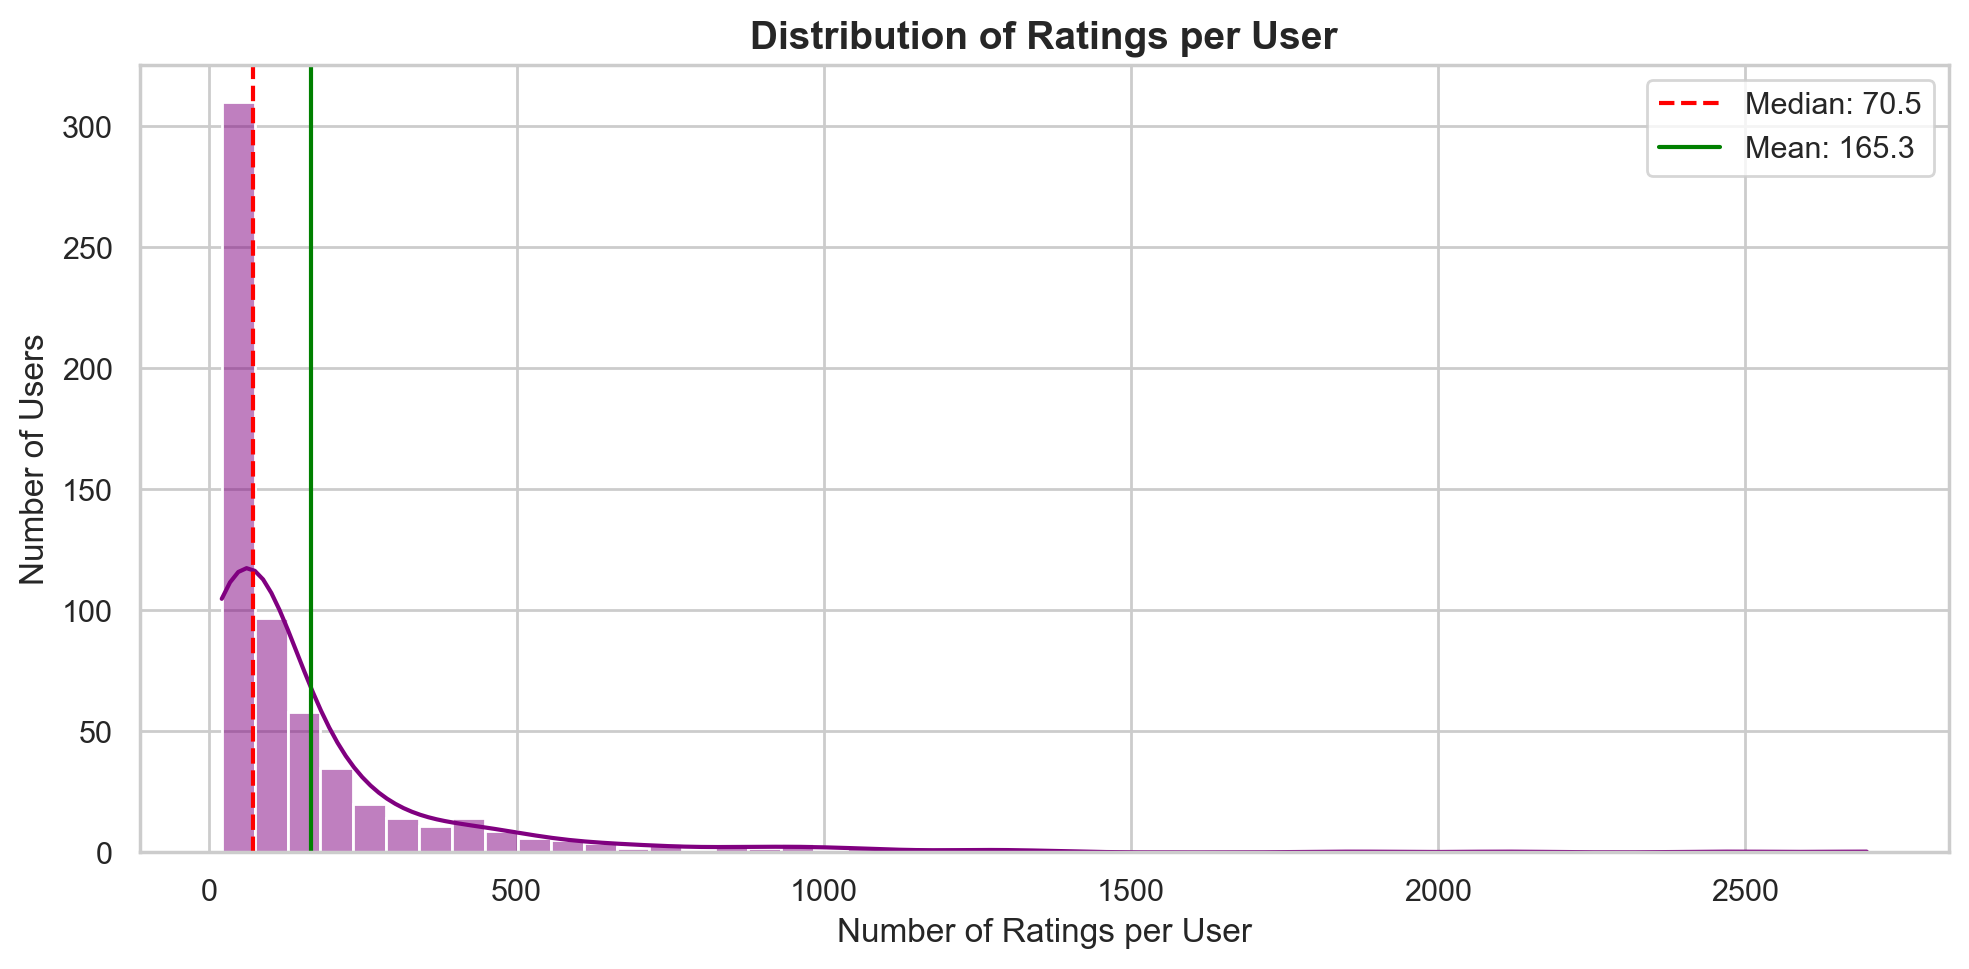

In [7]:
ratings_per_user = ratings.groupby('userId').size()

print("Descriptive statistics for ratings per user:")
print(ratings_per_user.describe())

# Visualize the distribution of ratings per user
plt.figure(figsize=(10, 5))
sns.histplot(ratings_per_user, bins=50, kde=True, color='purple')
plt.title('Distribution of Ratings per User', fontsize=14, fontweight='bold')
plt.xlabel('Number of Ratings per User', fontsize=12)
plt.ylabel('Number of Users', fontsize=12)
plt.axvline(ratings_per_user.median(), color='red', linestyle='--', label=f'Median: {ratings_per_user.median():.1f}')
plt.axvline(ratings_per_user.mean(), color='green', linestyle='-', label=f'Mean: {ratings_per_user.mean():.1f}')
plt.legend()
plt.tight_layout()
plt.show()

**Nhận xét:**
- Tất cả người dùng trong tập dữ liệu đều đã đánh giá **tối thiểu 20 bộ phim** (đúng như tiêu chuẩn lọc của MovieLens Small).
- Người dùng tích cực nhất đã đánh giá tới **2,698 bộ phim**, trong khi trung bình (mean) mỗi user đánh giá khoảng 165 phim.
- Khoảng 50% người dùng (trung vị) chỉ đánh giá từ 70 bộ phim trở xuống. Biểu đồ có hình dạng "đuôi dài" (long tail distribution) rất đặc trưng: phần lớn người dùng đánh giá ít phim, chỉ có một số rất ít người dùng cực kỳ tích cực đóng góp phần lớn số lượng đánh giá.

### 2.3 Phân tích ratings theo bộ phim (Movie popularity)

Chúng ta sẽ tìm hiểu xem mỗi bộ phim nhận được trung bình bao nhiêu lượt đánh giá và tìm ra những bộ phim nổi tiếng nhất.

Descriptive statistics for ratings per movie:
count    9724.000000
mean       10.369807
std        22.401005
min         1.000000
25%         1.000000
50%         3.000000
75%         9.000000
max       329.000000
dtype: float64

Top 10 most rated movies:


,movieId,title,genres,ratings_count
314,356,Forrest Gump (1994),Comedy|Drama|Romance|War,329
277,318,"Shawshank Redemption, The (1994)",Crime|Drama,317
257,296,Pulp Fiction (1994),Comedy|Crime|Drama|Thriller,307
510,593,"Silence of the Lambs, The (1991)",Crime|Horror|Thriller,279
1939,2571,"Matrix, The (1999)",Action|Sci-Fi|Thriller,278
224,260,Star Wars: Episode IV - A New Hope (1977),Action|Adventure|Sci-Fi,251
418,480,Jurassic Park (1993),Action|Adventure|Sci-Fi|Thriller,238
97,110,Braveheart (1995),Action|Drama|War,237
507,589,Terminator 2: Judgment Day (1991),Action|Sci-Fi,224
461,527,Schindler's List (1993),Drama|War,220


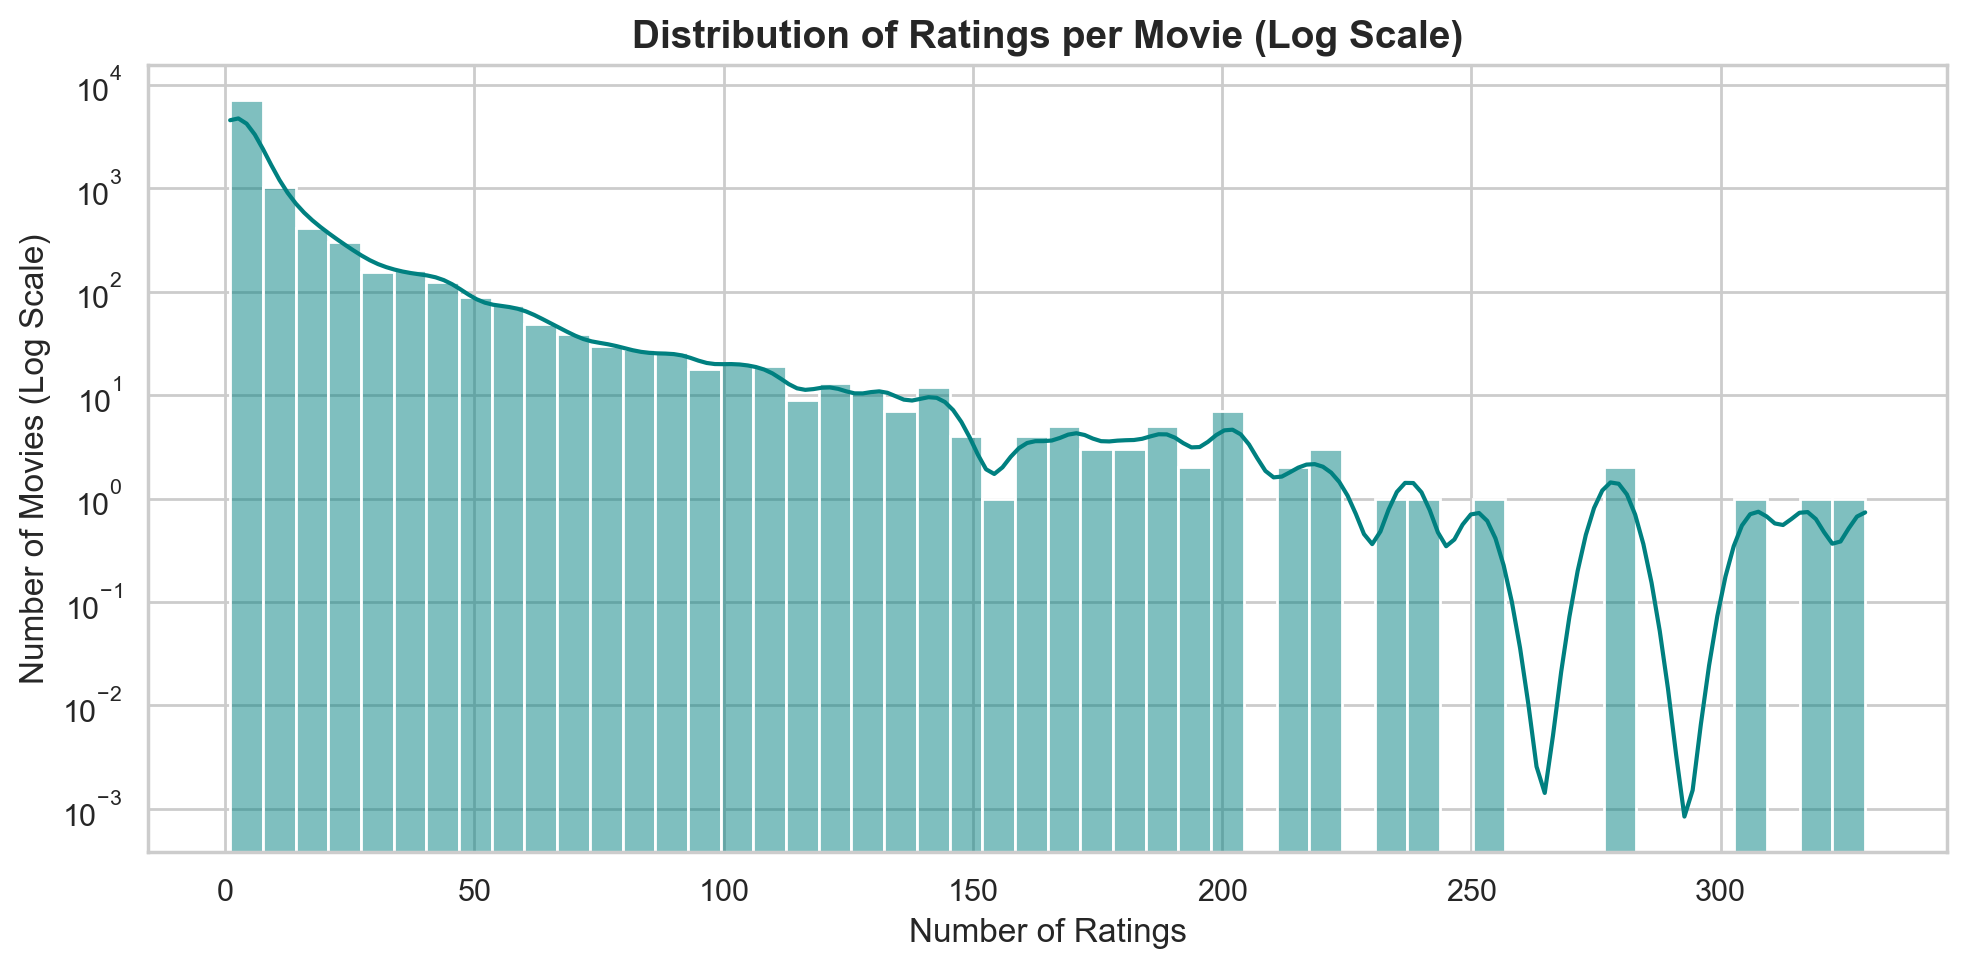

In [8]:
ratings_per_movie = ratings.groupby('movieId').size()
print("Descriptive statistics for ratings per movie:")
print(ratings_per_movie.describe())

# Get top 10 most rated movies
top_rated_movies = ratings_per_movie.sort_values(ascending=False).head(10)
top_rated_movies_info = movies[movies['movieId'].isin(top_rated_movies.index)].copy()
top_rated_movies_info['ratings_count'] = top_rated_movies_info['movieId'].map(ratings_per_movie)
top_rated_movies_info = top_rated_movies_info.sort_values(by='ratings_count', ascending=False)

print("\nTop 10 most rated movies:")
display(top_rated_movies_info[['movieId', 'title', 'genres', 'ratings_count']])

# Visualize rating count distribution per movie
plt.figure(figsize=(10, 5))
sns.histplot(ratings_per_movie, bins=50, kde=True, color='teal')
plt.title('Distribution of Ratings per Movie (Log Scale)', fontsize=14, fontweight='bold')
plt.xlabel('Number of Ratings', fontsize=12)
plt.ylabel('Number of Movies (Log Scale)', fontsize=12)
plt.yscale('log') # Use log scale for Y-axis for better visibility
plt.tight_layout()
plt.show()

**Nhận xét:**
- Hơn một nửa số phim trong tập dữ liệu (50%) nhận được **tối đa 3 lượt đánh giá**. Thậm chí có tới 3,446 bộ phim (chiếm khoảng 35%) chỉ nhận được đúng 1 lượt đánh giá duy nhất. Đây là hiện tượng **sự thưa thớt của dữ liệu (Data Sparsity)** rất lớn trong hệ gợi ý.
- Bộ phim được đánh giá nhiều nhất là **Forrest Gump (1994)** với 329 lượt đánh giá, theo sau lần lượt là *Shawshank Redemption, The (1994)* và *Pulp Fiction (1994)*. Đây đều là những kiệt tác điện ảnh nổi tiếng toàn cầu.

### 2.4 Mối quan hệ giữa Điểm đánh giá trung bình và Số lượng ratings của mỗi bộ phim

Chúng ta sẽ xem liệu các phim được đánh giá nhiều (phổ biến) có xu hướng được chấm điểm cao hay thấp hơn các phim ít người xem.

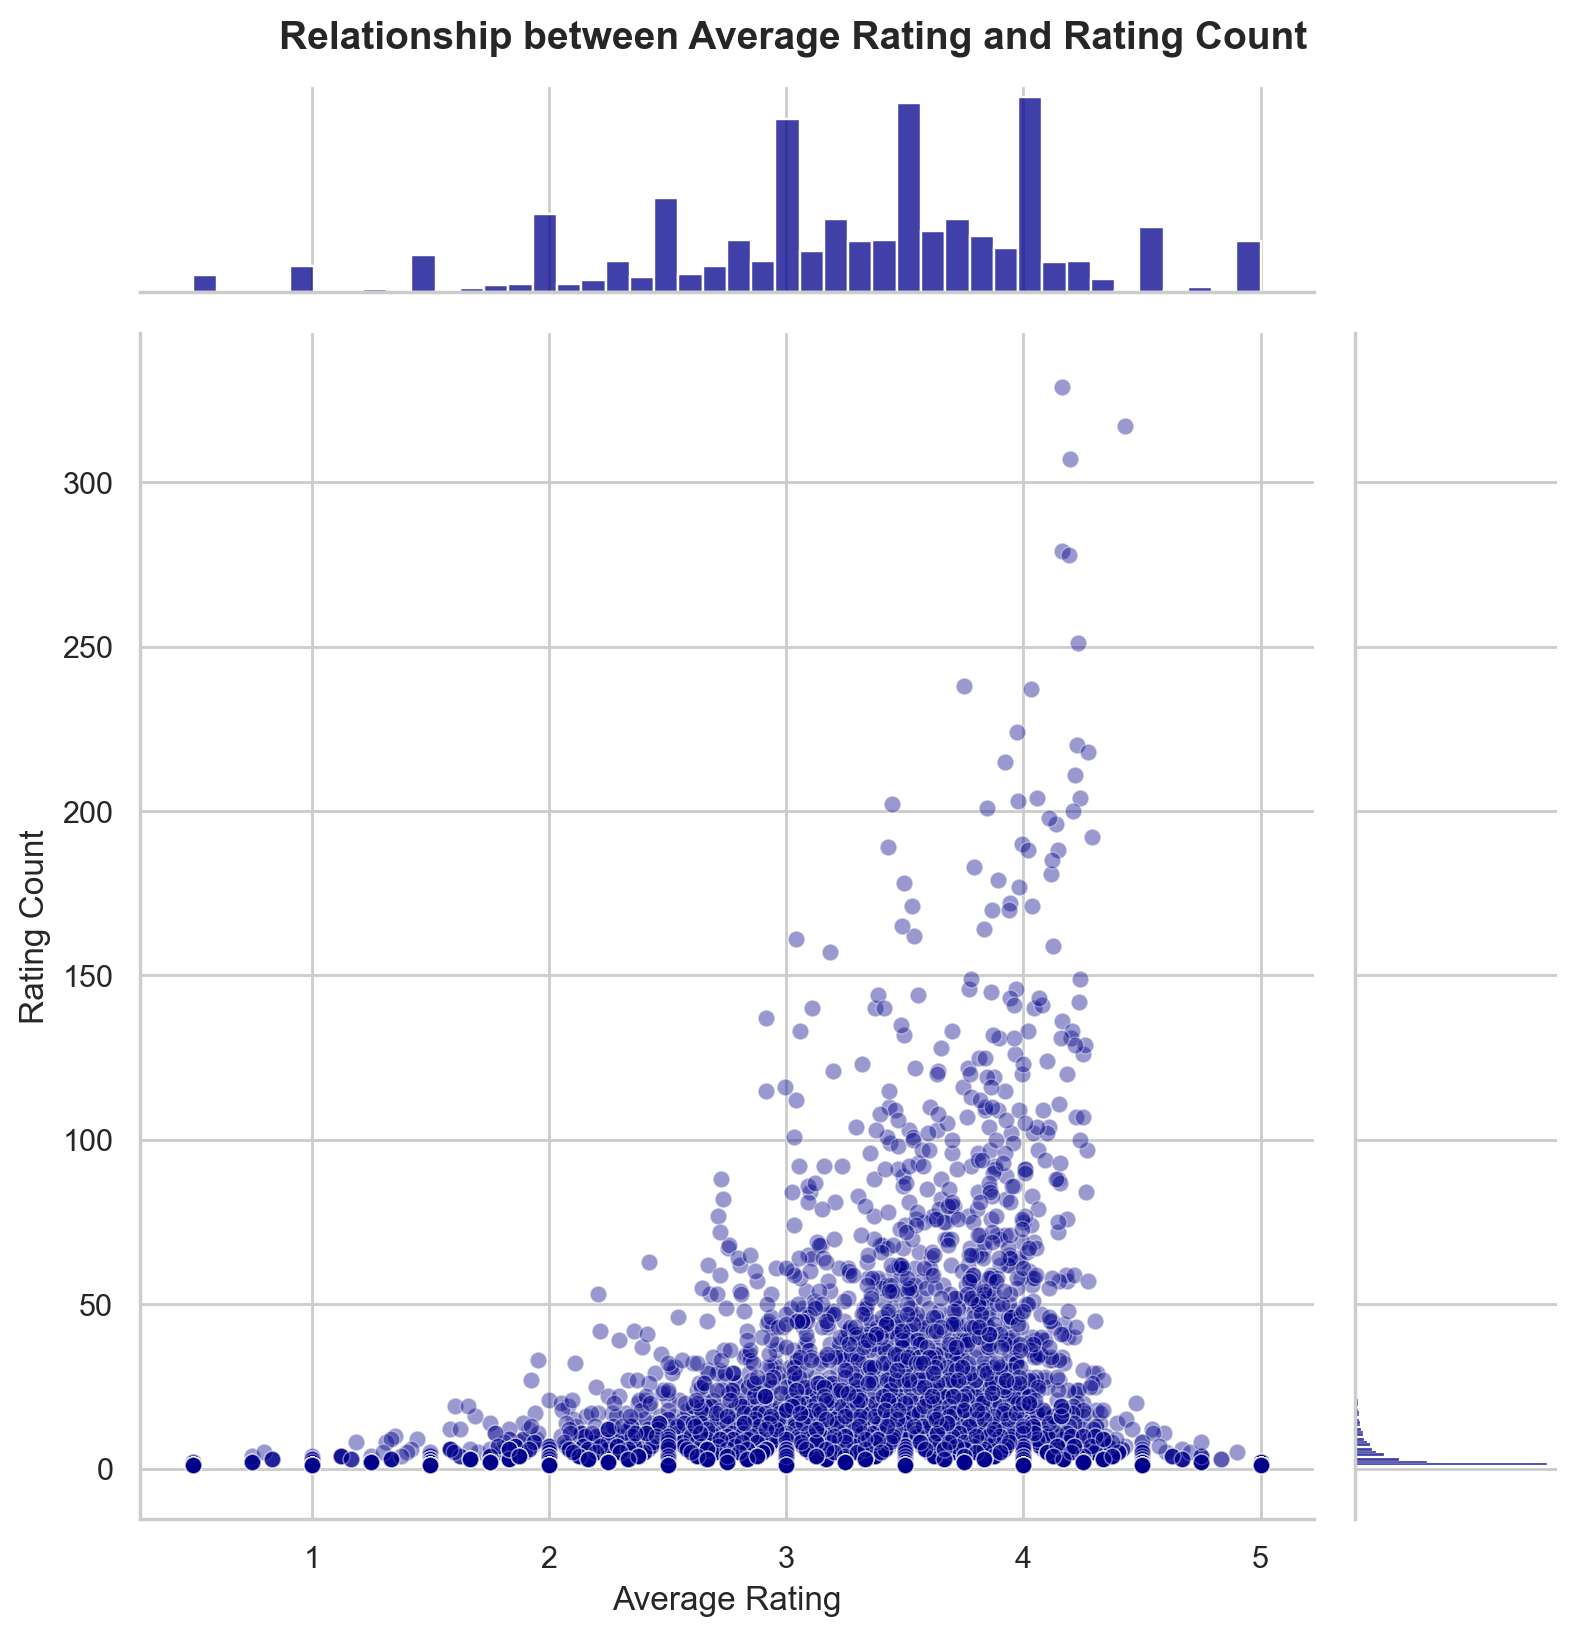

In [9]:
# Calculate average rating and rating count for each movie
movie_stats = ratings.groupby('movieId').agg(
    rating_mean=('rating', 'mean'),
    rating_count=('rating', 'count')
).reset_index()

# Merge with movie info
movie_stats = pd.merge(movie_stats, movies[['movieId', 'title']], on='movieId')

# Plot joint distribution
g = sns.jointplot(x='rating_mean', y='rating_count', data=movie_stats, 
                  alpha=0.4, color='darkblue', height=8, ratio=5)
g.fig.suptitle('Relationship between Average Rating and Rating Count', y=1.02, fontsize=14, fontweight='bold')
g.set_axis_labels('Average Rating', 'Rating Count', fontsize=12)
plt.show()

**Nhận xét:**
- Những bộ phim có điểm đánh giá trung bình cực kỳ cao (ví dụ: đúng 5.0) hoặc cực kỳ thấp (ví dụ: đúng 0.5) hầu hết có số lượng ratings rất thấp (thường chỉ 1 hoặc 2 ratings). Điểm số này không mang nhiều tính đại diện vì kích thước mẫu quá nhỏ.
- Ngược lại, các bộ phim phổ biến (có nhiều lượt đánh giá, nằm ở phía trên của biểu đồ) có xu hướng tập trung ở mức điểm đánh giá từ **3.5 đến 4.5 sao**. Điều này hợp lý vì những bộ phim hay, chất lượng tốt mới thu hút được lượng người xem và đánh giá đông đảo. Điểm số của chúng cũng hội tụ về giá trị thực hơn.

## Phần 3: Phân tích Thông tin Phim và Thể loại (Movies & Genres)

Bảng `movies` lưu trữ thông tin thuộc tính của các bộ phim. Chúng ta sẽ phân tích sâu hơn về:
1. Năm phát hành phim (trích xuất từ tiêu đề).
2. Sự phân bố của các thể loại phim.
3. Điểm đánh giá trung bình của từng thể loại phim.

Number of movies missing release year: 24


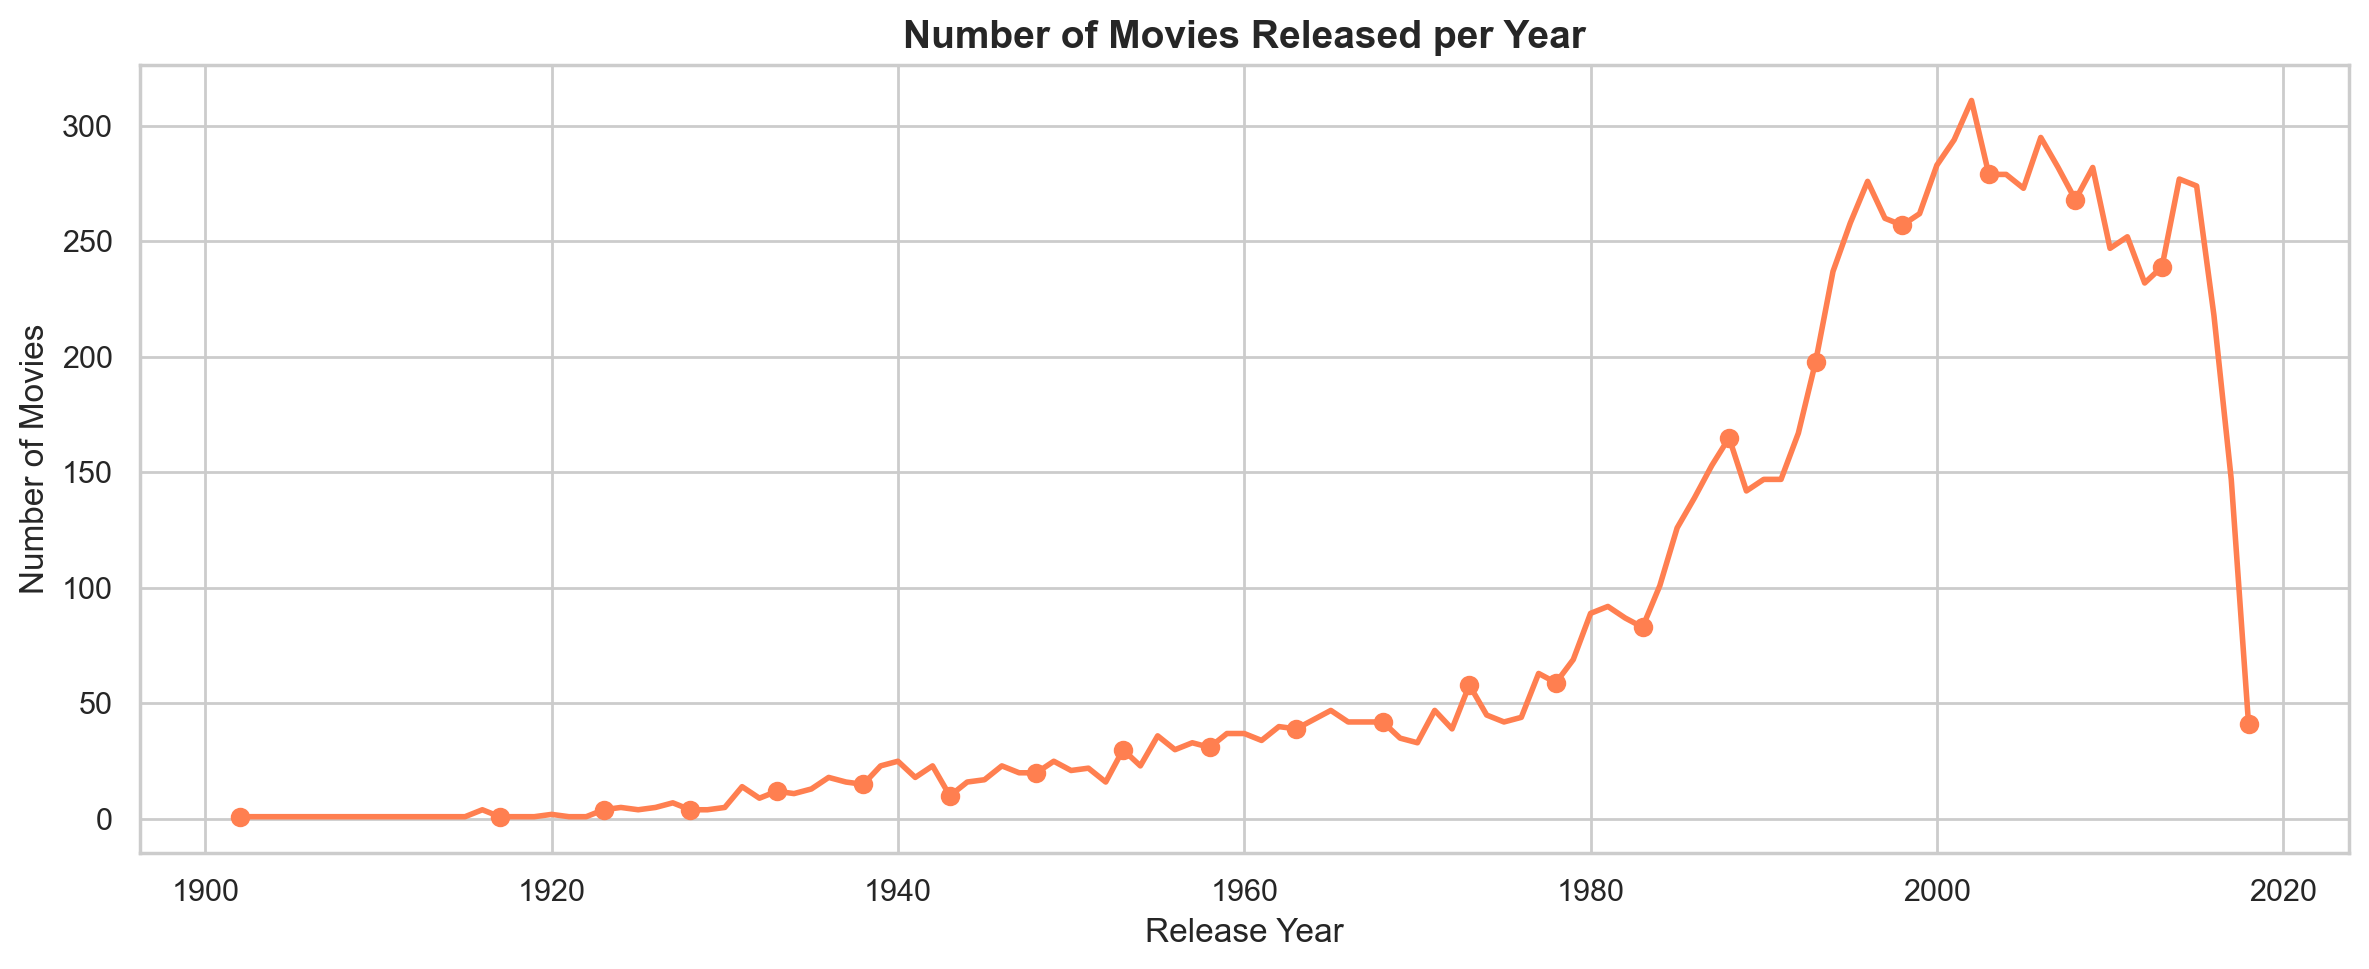

In [10]:
# Extract release year from movie title using regex (e.g. "Toy Story (1995)" -> 1995)
movies['year'] = movies['title'].str.extract(r'\((\d{4})\)$')

# Convert to numeric, handle errors
movies['year'] = pd.to_numeric(movies['year'], errors='coerce')

print("Number of movies missing release year:", movies['year'].isna().sum())

# Drop missing year rows for temporal analysis
movies_with_year = movies.dropna(subset=['year']).copy()
movies_with_year['year'] = movies_with_year['year'].astype(int)

# Count movies per year
movies_per_year = movies_with_year['year'].value_counts().sort_index()

plt.figure(figsize=(12, 5))
plt.plot(movies_per_year.index, movies_per_year.values, color='coral', marker='o', markevery=5, linewidth=2)
plt.title('Number of Movies Released per Year', fontsize=14, fontweight='bold')
plt.xlabel('Release Year', fontsize=12)
plt.ylabel('Number of Movies', fontsize=12)
plt.tight_layout()
plt.show()

**Nhận xét:**
- Số lượng phim tăng dần theo thời gian, đặc biệt bùng nổ mạnh mẽ kể từ những năm 1990 và đạt đỉnh điểm vào những năm 2000-2015.
- Điều này phản ánh xu hướng phát triển chung của ngành công nghiệp điện ảnh toàn cầu và sự cập nhật liên tục của cơ sở dữ liệu MovieLens.

### 3.2 Phân tích các Thể loại Phim (Genres)

Mỗi bộ phim có thể thuộc nhiều thể loại, các thể loại được ngăn cách bởi dấu gạch đứng (`|`). Ta cần tách chúng ra để thống kê tần suất xuất hiện của từng thể loại.

Number of unique genres: 20

Genre frequencies:


Drama                 4361
Comedy                3756
Thriller              1894
Action                1828
Romance               1596
Adventure             1263
Crime                 1199
Sci-Fi                 980
Horror                 978
Fantasy                779
Children               664
Animation              611
Mystery                573
Documentary            440
War                    382
Musical                334
Western                167
IMAX                   158
Film-Noir               87
(no genres listed)      34
Name: count, dtype: int64

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_27756\118164740.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=genres_counts.values, y=genres_counts.index, palette='viridis')


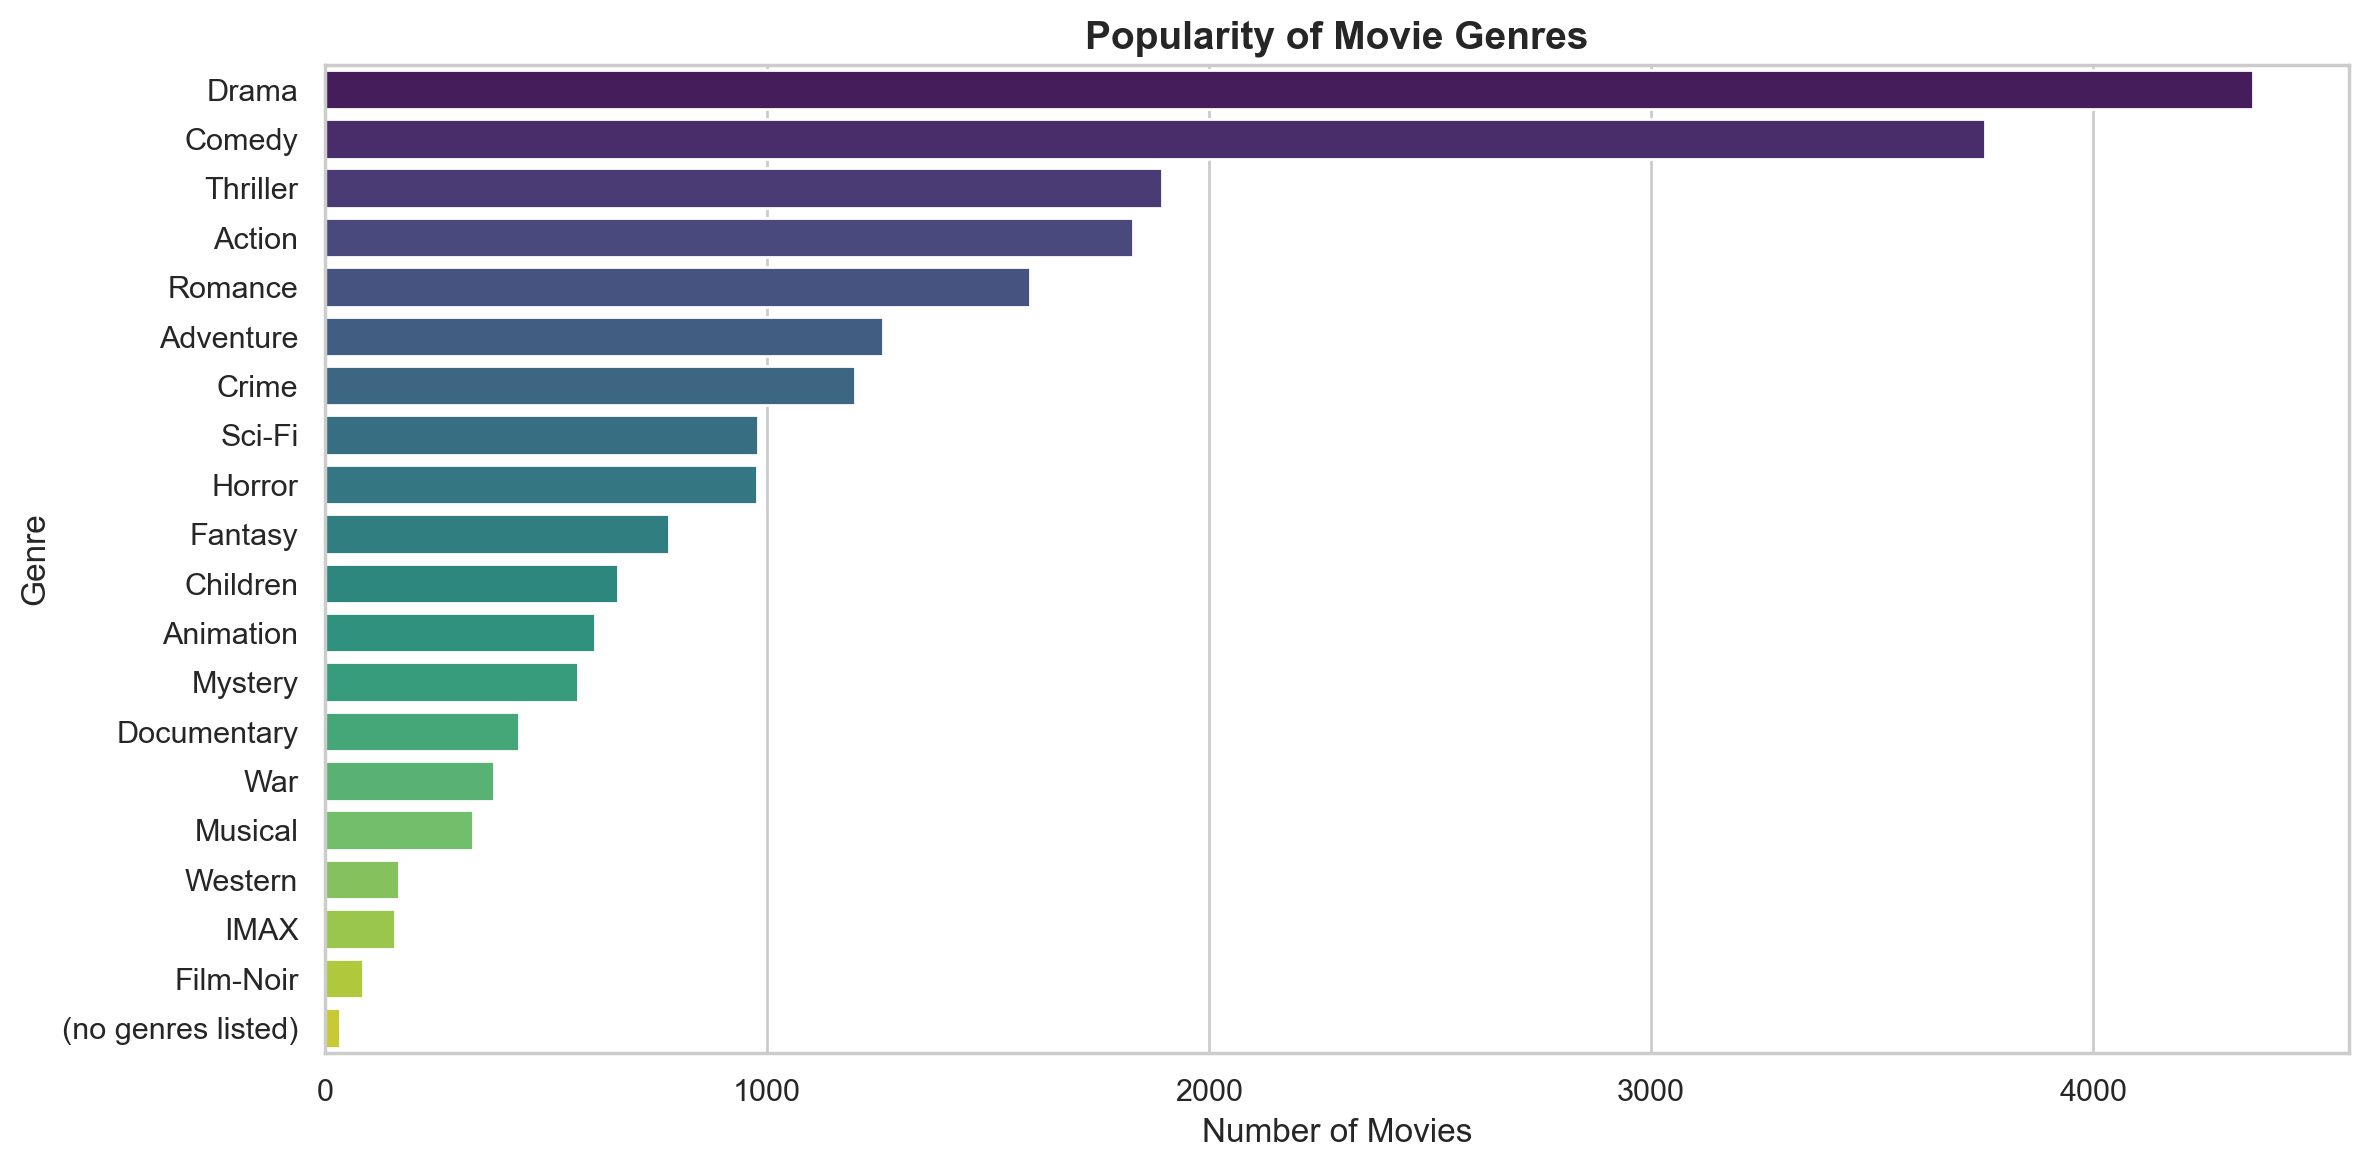

In [11]:
# Split genres and flatten the list
genres_split = movies['genres'].str.split('|')
all_genres = [genre for sublist in genres_split for genre in sublist]
genres_series = pd.Series(all_genres)

# Count genre frequencies
genres_counts = genres_series.value_counts()

print(f"Number of unique genres: {len(genres_counts)}")
print("\nGenre frequencies:")
display(genres_counts)

# Plot genre distribution
plt.figure(figsize=(12, 6))
sns.barplot(x=genres_counts.values, y=genres_counts.index, hue=genres_counts.index, legend=False, palette='viridis')
plt.title('Popularity of Movie Genres', fontsize=14, fontweight='bold')
plt.xlabel('Number of Movies', fontsize=12)
plt.ylabel('Genre', fontsize=12)
plt.tight_layout()
plt.show()

**Nhận xét:**
- Thể loại phổ biến nhất là **Drama** (Kịch tính/Tâm lý) với hơn 4,300 phim, tiếp theo là **Comedy** (Hài kịch) với gần 3,800 phim. Đây là hai dòng phim phổ thông và chiếm số lượng lớn nhất.
- Các thể loại ít phổ biến nhất là **Film-Noir** và **Western** (Miền viễn tây).
- Có một nhãn đặc biệt là `(no genres listed)` đại diện cho các phim chưa được xếp loại.

### 3.3 Điểm đánh giá trung bình của từng thể loại phim

Chúng ta sẽ ghép bảng ratings và bảng movies để tính toán điểm đánh giá trung bình của từng thể loại.

Ratings statistics by genre:


,mean_rating,count_rating
genres,,
Film-Noir,3.920115,870
War,3.808294,4859
Documentary,3.797785,1219
Crime,3.658294,16681
Drama,3.656184,41928
Mystery,3.632460,7674
Animation,3.629937,6988
IMAX,3.618335,4145
Western,3.583938,1930


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_27756\3859274292.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=genre_rating_stats['mean_rating'], y=genre_rating_stats.index, palette='coolwarm')


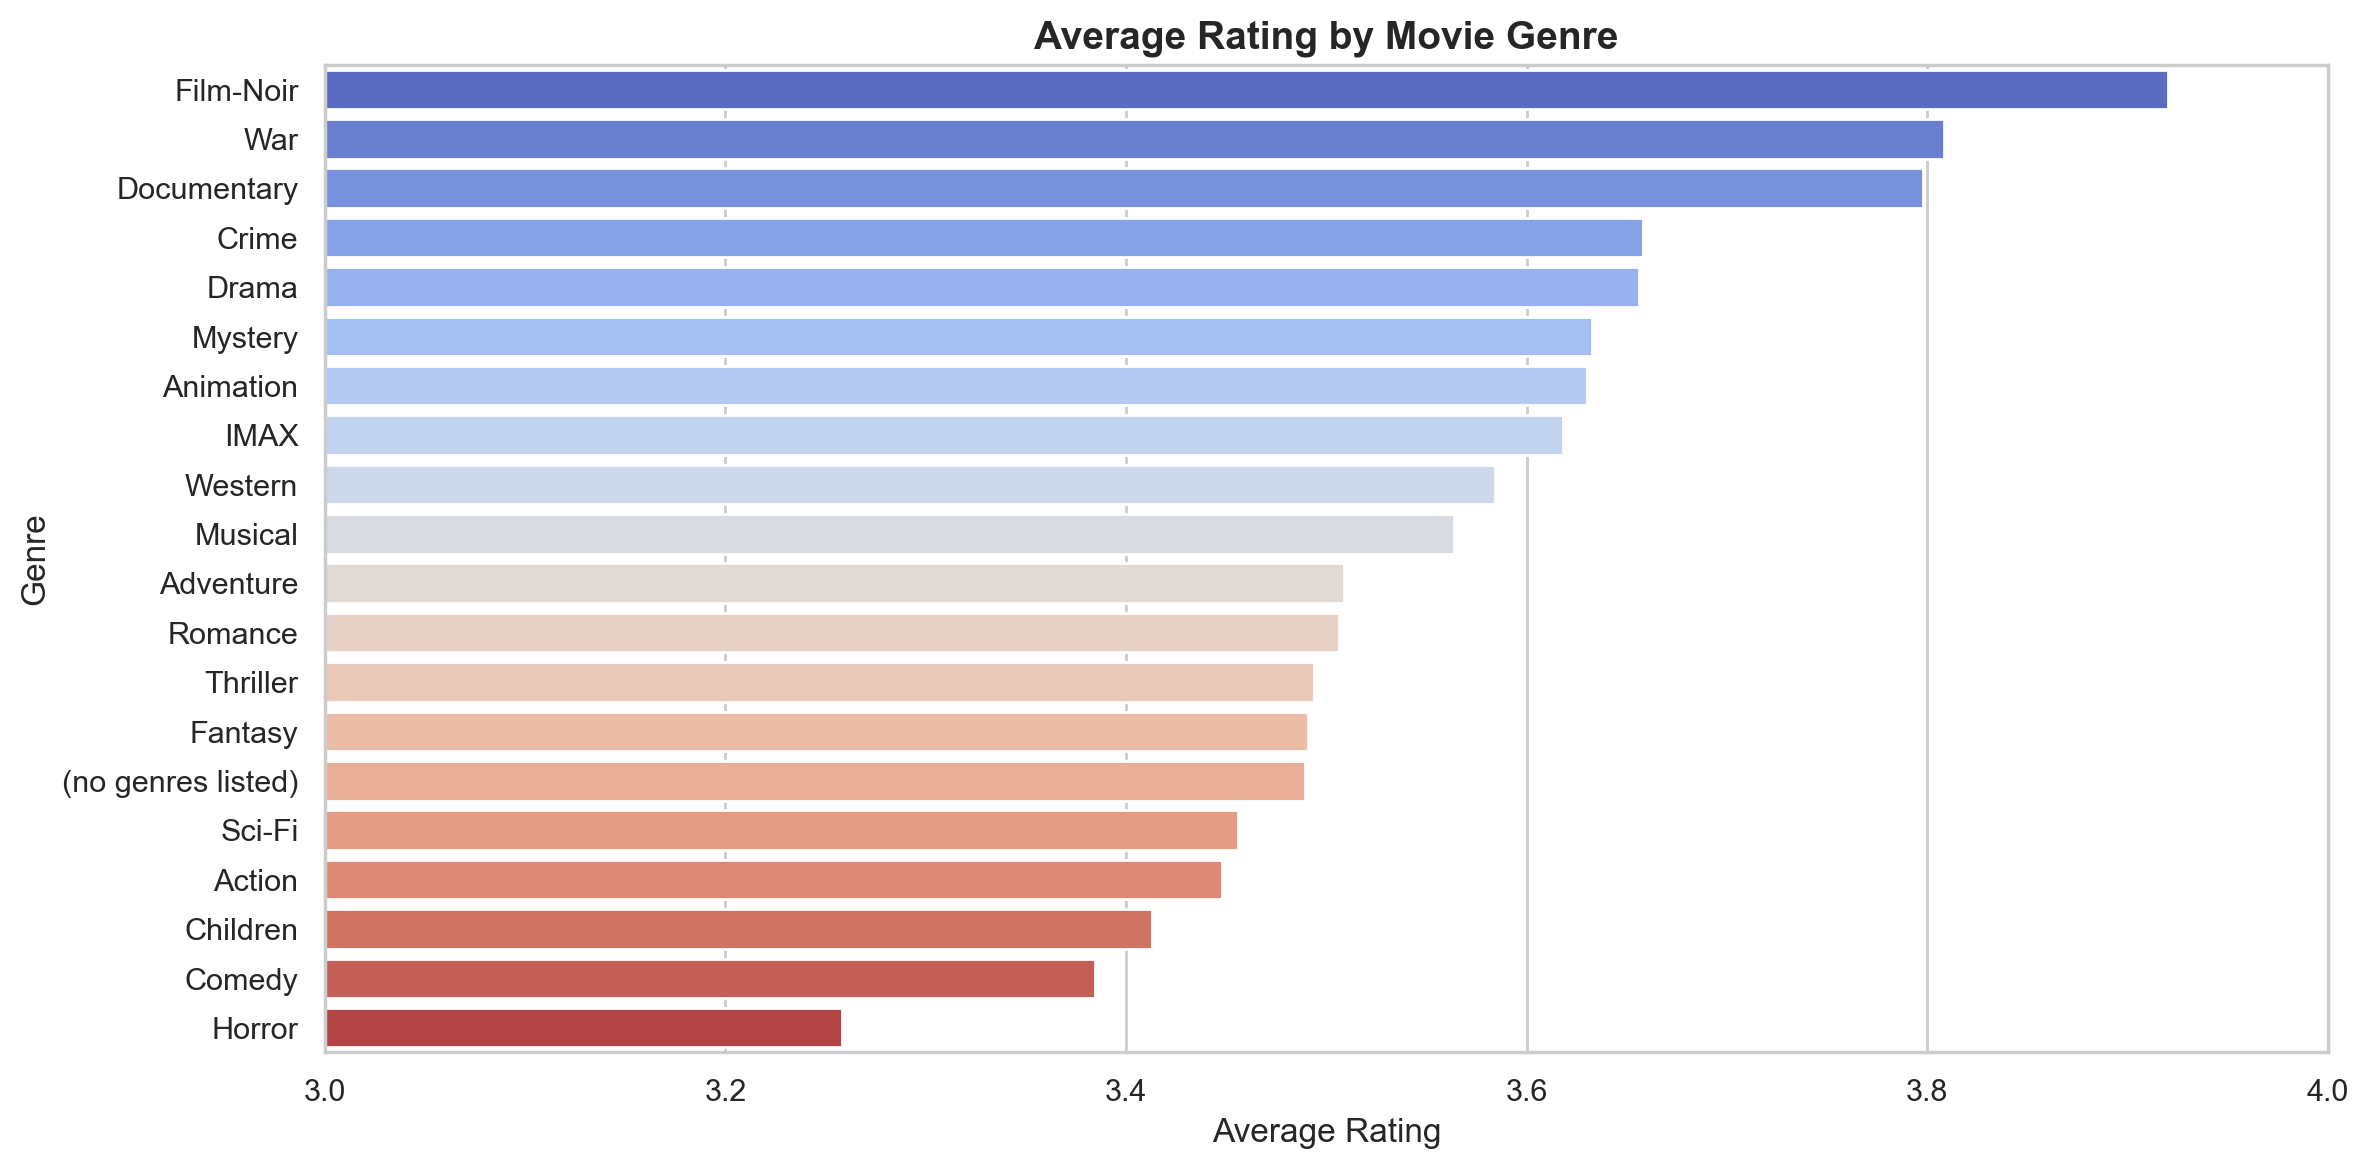

In [12]:
# Merge ratings and movies
ratings_movies = pd.merge(ratings, movies, on='movieId')

# Explode genres list to single genre per row
ratings_movies_exploded = ratings_movies.copy()
ratings_movies_exploded['genres'] = ratings_movies_exploded['genres'].str.split('|')
ratings_movies_exploded = ratings_movies_exploded.explode('genres')

# Calculate mean rating and count per genre
genre_rating_stats = ratings_movies_exploded.groupby('genres').agg(
    mean_rating=('rating', 'mean'),
    count_rating=('rating', 'count')
).sort_values(by='mean_rating', ascending=False)

print("Ratings statistics by genre:")
display(genre_rating_stats)

# Plot average rating by movie genre
plt.figure(figsize=(12, 6))
sns.barplot(x=genre_rating_stats['mean_rating'], y=genre_rating_stats.index, hue=genre_rating_stats.index, legend=False, palette='coolwarm')
plt.title('Average Rating by Movie Genre', fontsize=14, fontweight='bold')
plt.xlabel('Average Rating', fontsize=12)
plt.ylabel('Genre', fontsize=12)
plt.xlim(3.0, 4.0) # Focus range for better comparison
plt.tight_layout()
plt.show()

**Nhận xét:**
- Thể loại **Film-Noir** có điểm trung bình cao nhất (khoảng 3.92), theo sau là **War** (3.81) và **Documentary** (3.80). Đây là những thể loại phim thường kén người xem nhưng nhận được đánh giá rất nghiêm túc từ giới phê bình hoặc người dùng trung thành.
- Các thể loại phổ biến nhất như **Comedy** hay **Action** lại có điểm trung bình ở mức vừa phải (khoảng 3.38 - 3.45).
- Thể loại bị đánh giá thấp nhất nói chung là **Horror** (Kinh dị) với điểm trung bình khoảng 3.26.

## Phần 4: Phân tích Thẻ gắn của Người dùng (Tags)

Bảng `tags` chứa thông tin các từ khóa dạng tự do do người dùng gắn cho phim để mô tả nội dung, phong cách hay cảm nhận cá nhân.

Top 20 most frequent tags:


tag
In Netflix queue      131
atmospheric            36
thought-provoking      24
superhero              24
funny                  23
surreal                23
Disney                 23
religion               22
sci-fi                 21
quirky                 21
dark comedy            21
psychology             21
suspense               20
twist ending           19
visually appealing     19
crime                  19
politics               18
mental illness         16
music                  16
time travel            16
Name: count, dtype: int64

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_27756\1335929166.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_tags.values, y=top_tags.index, palette='mako')


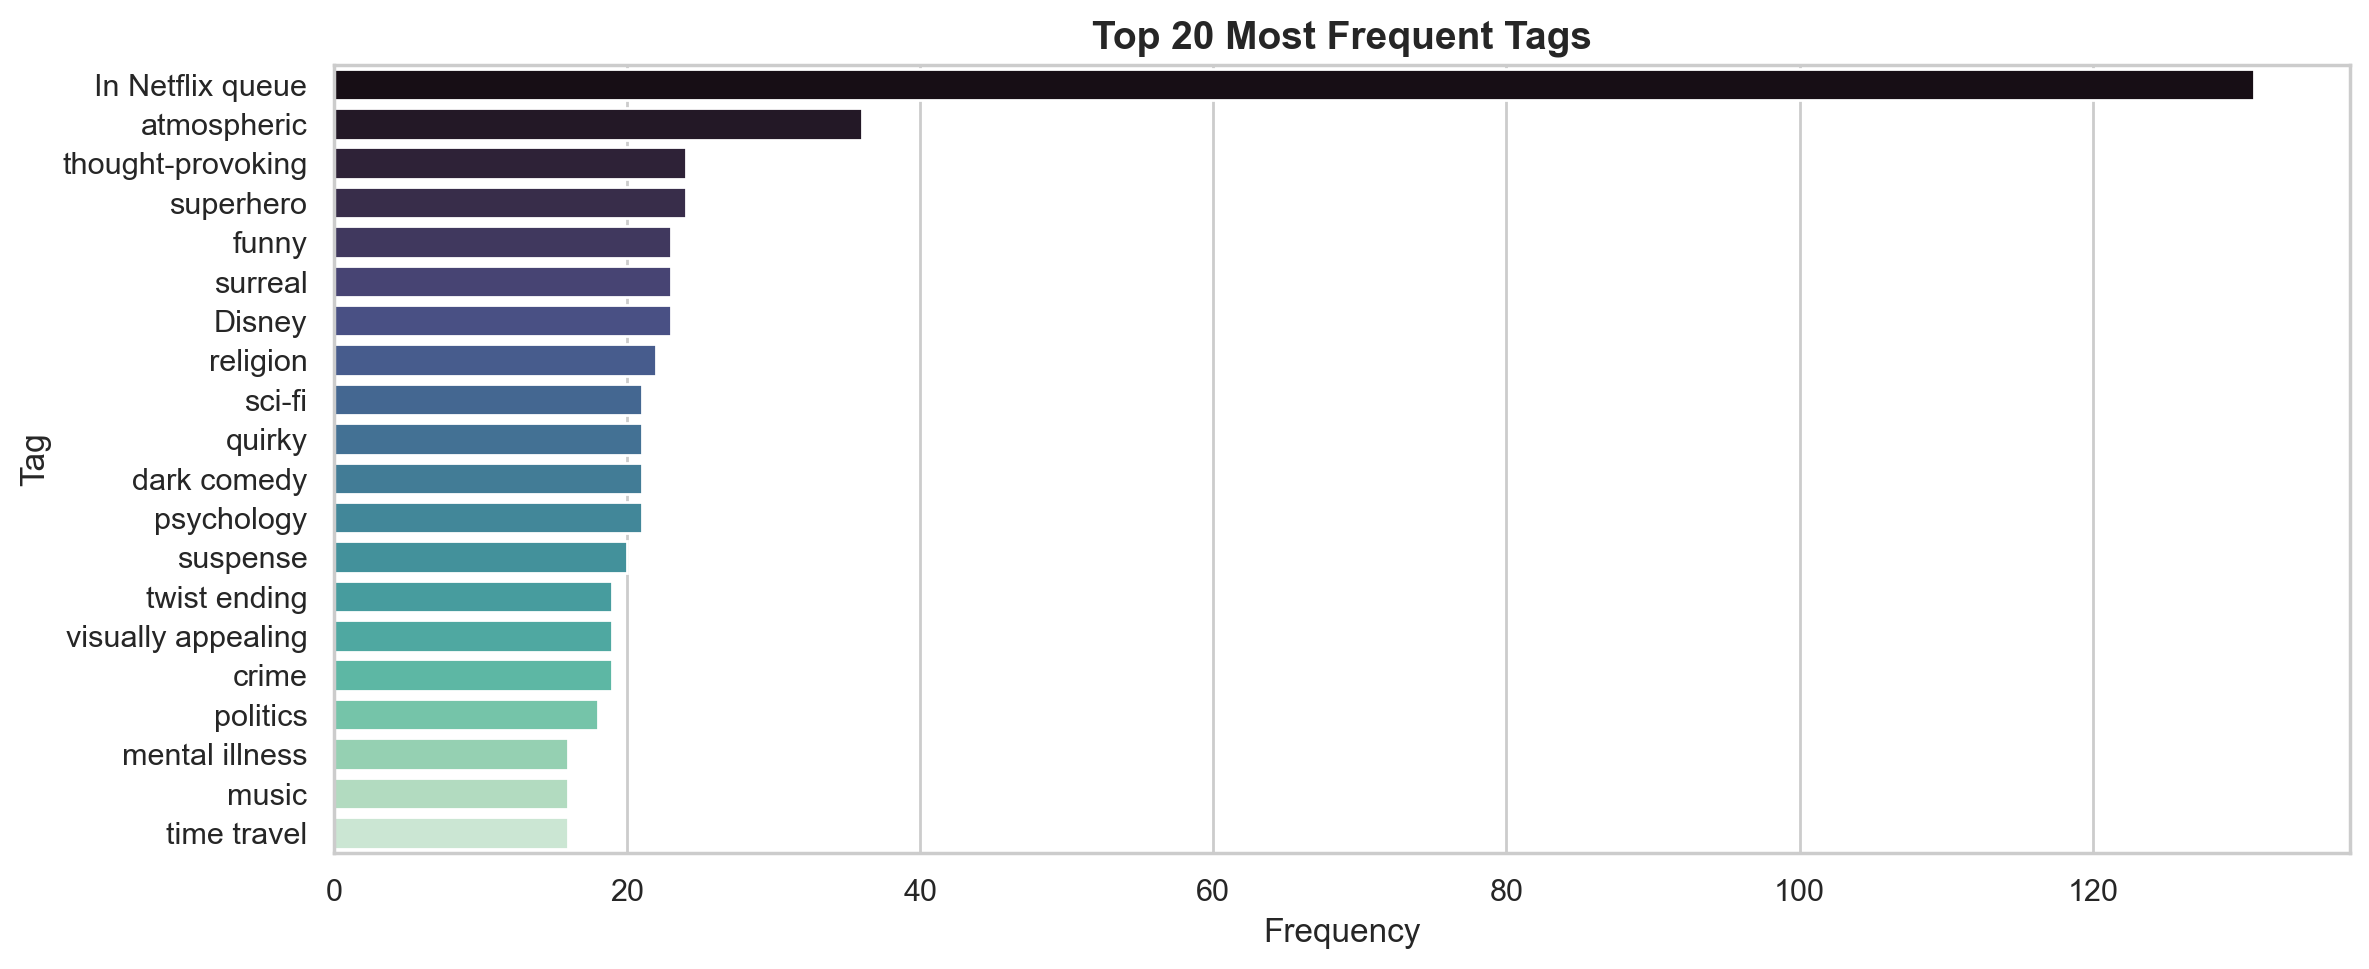

In [13]:
# Count tag frequencies
top_tags = tags['tag'].value_counts().head(20)

print("Top 20 most frequent tags:")
display(top_tags)

# Plot top tags
plt.figure(figsize=(12, 5))
sns.barplot(x=top_tags.values, y=top_tags.index, hue=top_tags.index, legend=False, palette='mako')
plt.title('Top 20 Most Frequent Tags', fontsize=14, fontweight='bold')
plt.xlabel('Frequency', fontsize=12)
plt.ylabel('Tag', fontsize=12)
plt.tight_layout()
plt.show()

In [14]:
# Generate Word Cloud from tags
try:
    from wordcloud import WordCloud
    
    # Join all tags into a single string
    tags_text = ' '.join(tags['tag'].dropna().astype(str).tolist())
    
    wordcloud = WordCloud(width=800, height=400, background_color='white', 
                          colormap='Dark2', max_words=100).generate(tags_text)
    
    plt.figure(figsize=(12, 6))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title('Word Cloud of Movie Tags', fontsize=16, fontweight='bold', pad=20)
    plt.tight_layout()
    plt.show()
except ImportError:
    print("Wordcloud library is not installed. Skipping word cloud visualization. To enable, run 'pip install wordcloud' in terminal.")

Wordcloud library is not installed. Skipping word cloud visualization. To enable, run 'pip install wordcloud' in terminal.


### Tìm các bộ phim được gắn thẻ nhiều nhất

In [15]:
# Count tags per movie
tags_per_movie = tags.groupby('movieId').size().sort_values(ascending=False).head(10)
tags_per_movie_info = movies[movies['movieId'].isin(tags_per_movie.index)].copy()
tags_per_movie_info['tags_count'] = tags_per_movie_info['movieId'].map(tags_per_movie)
tags_per_movie_info = tags_per_movie_info.sort_values(by='tags_count', ascending=False)

print("Top 10 most tagged movies:")
display(tags_per_movie_info[['movieId', 'title', 'genres', 'tags_count']])

Top 10 most tagged movies:


,movieId,title,genres,tags_count
257,296,Pulp Fiction (1994),Comedy|Crime|Drama|Thriller,181
2226,2959,Fight Club (1999),Action|Crime|Drama|Thriller,54
706,924,2001: A Space Odyssey (1968),Adventure|Drama|Sci-Fi,41
254,293,Léon: The Professional (a.k.a. The Professiona...,Action|Crime|Drama|Thriller,35
4909,7361,Eternal Sunshine of the Spotless Mind (2004),Drama|Romance|Sci-Fi,34
1298,1732,"Big Lebowski, The (1998)",Comedy|Crime,32
3562,4878,Donnie Darko (2001),Drama|Mystery|Sci-Fi|Thriller,29
224,260,Star Wars: Episode IV - A New Hope (1977),Action|Adventure|Sci-Fi,26
7372,79132,Inception (2010),Action|Crime|Drama|Mystery|Sci-Fi|Thriller|IMAX,26
8915,135536,Suicide Squad (2016),Action|Crime|Sci-Fi,19


**Nhận xét:**
- Các tag phổ biến được người dùng gắn liên quan trực tiếp đến cảm nhận, thể loại con hay thuộc tính đặc trưng như: **Inception**, **atmospheric**, **superhero**, **funny**, **surreal**, **sci-fi**.
- Bộ phim được gắn nhiều tags nhất là **Pulp Fiction (1994)** với 181 tags, tiếp theo là **Fight Club (1999)** với 54 tags. Đây cũng là những bộ phim kinh điển có cốt truyện vô cùng độc đáo kích thích người dùng thảo luận.

## Phần 5: Phân tích Xu hướng theo Thời gian (Temporal Analysis)

Chúng ta sẽ chuyển đổi `timestamp` trong bảng `ratings` sang kiểu dữ liệu thời gian thực (`datetime`) và phân tích:
1. Số lượng ratings được tạo ra qua các năm để thấy tính năng động của cộng đồng người dùng.
2. Điểm đánh giá trung bình qua các năm.

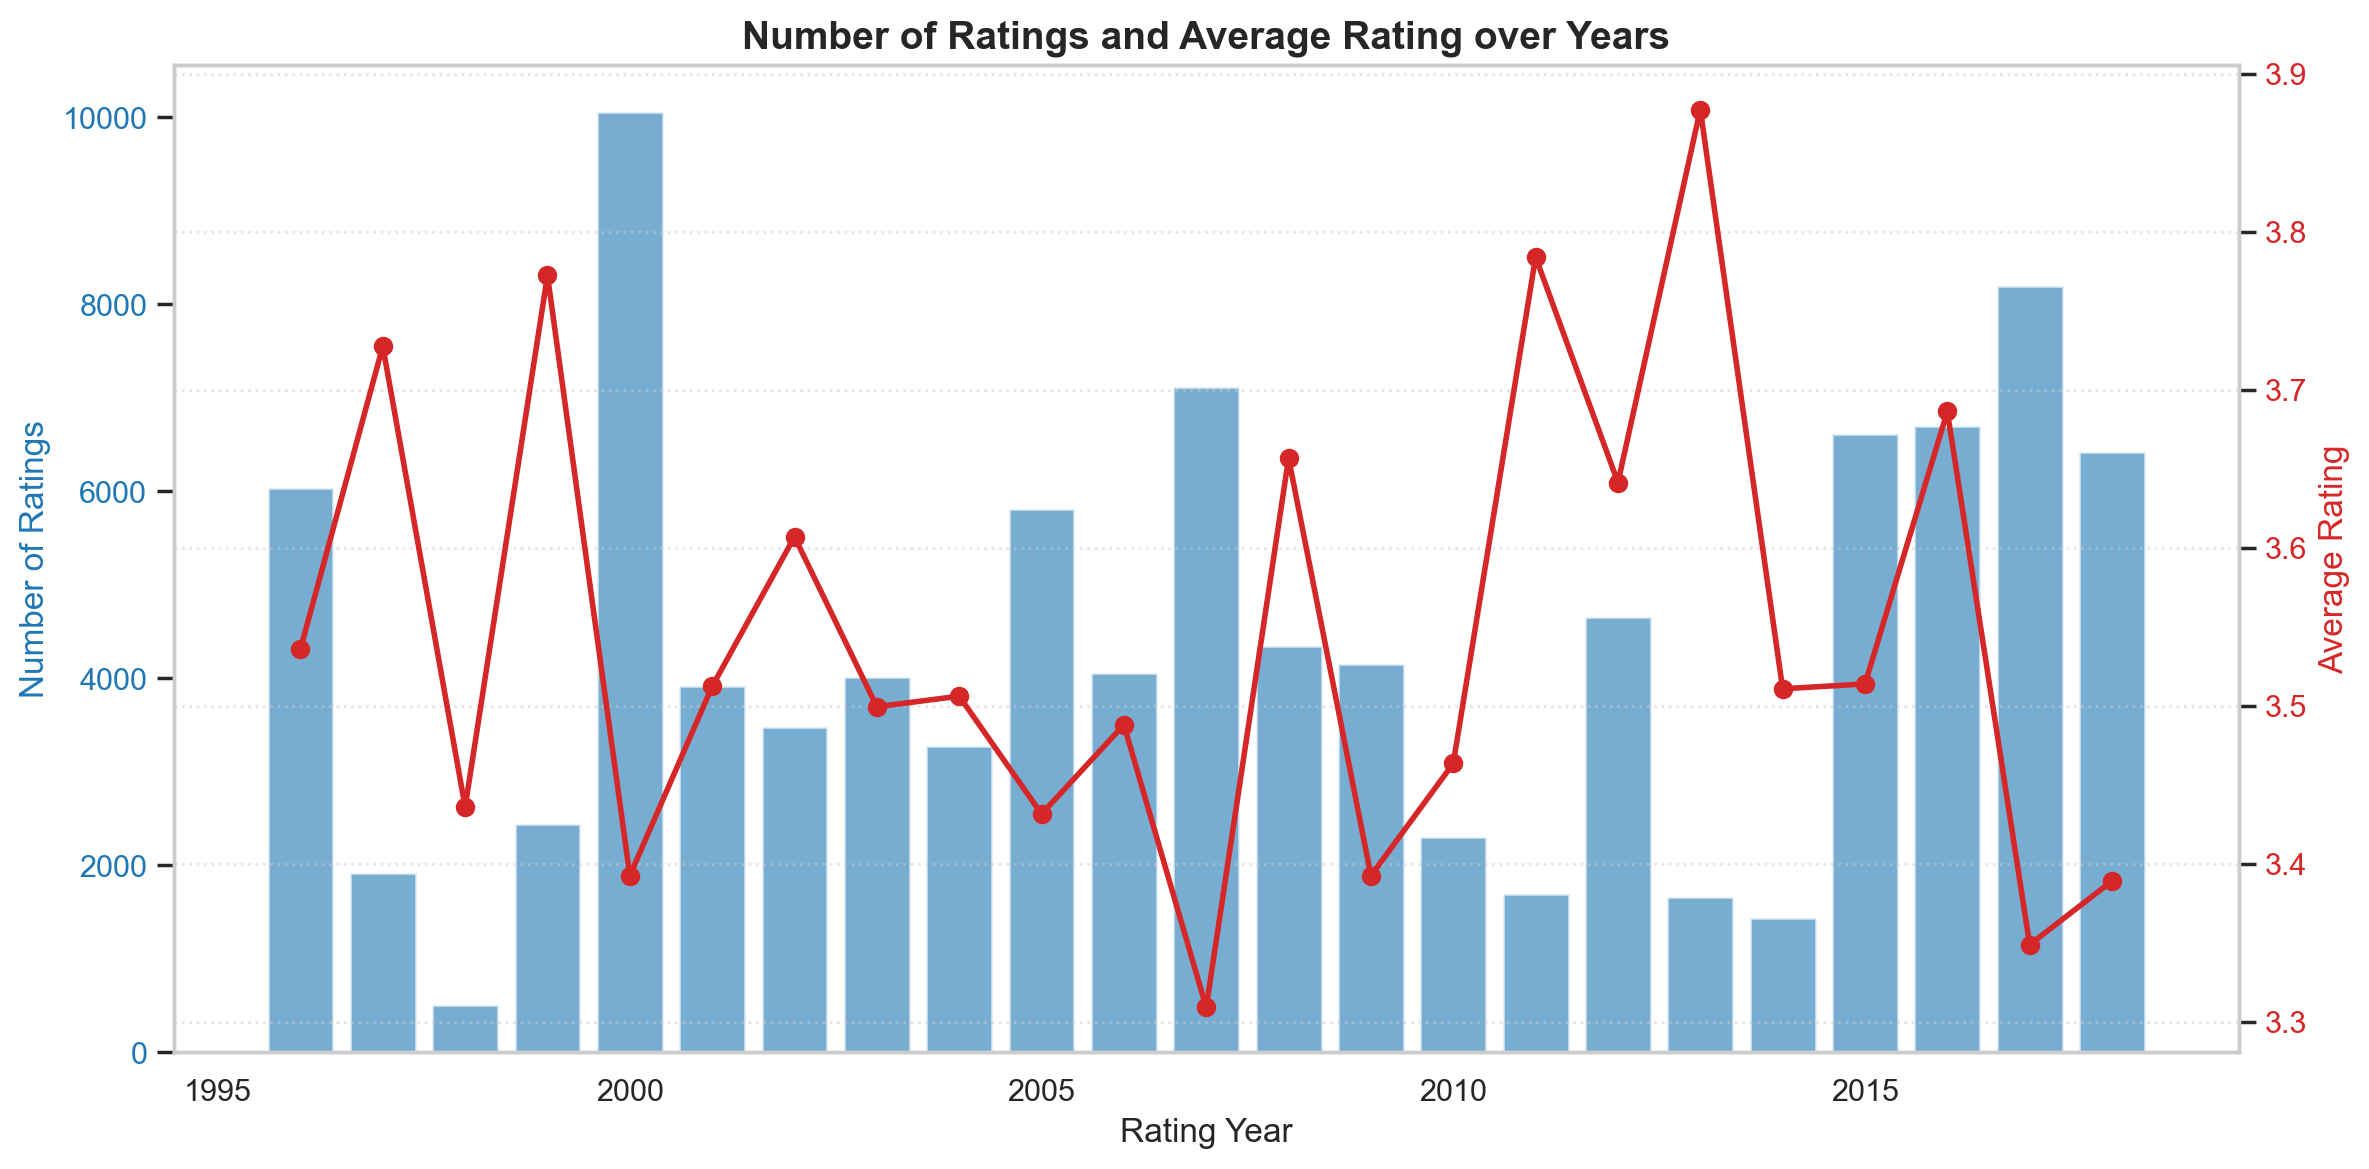

In [16]:
# Convert timestamp to datetime
ratings['datetime'] = pd.to_datetime(ratings['timestamp'], unit='s')
ratings['rating_year'] = ratings['datetime'].dt.year

# Group ratings by year
ratings_by_year = ratings.groupby('rating_year').size()

# Calculate average rating by year
avg_rating_by_year = ratings.groupby('rating_year')['rating'].mean()

# Plot rating count and average rating over years
fig, ax1 = plt.subplots(figsize=(12, 6))

color = 'tab:blue'
ax1.set_xlabel('Rating Year', fontsize=12)
ax1.set_ylabel('Number of Ratings', color=color, fontsize=12)
ax1.bar(ratings_by_year.index, ratings_by_year.values, color=color, alpha=0.6, label='Number of Ratings')
ax1.tick_params(axis='y', labelcolor=color)
ax1.grid(False)

ax2 = ax1.twinx()  
color = 'tab:red'
ax2.set_ylabel('Average Rating', color=color, fontsize=12)
ax2.plot(avg_rating_by_year.index, avg_rating_by_year.values, color=color, marker='o', linewidth=2, label='Average Rating')
ax2.tick_params(axis='y', labelcolor=color)
ax2.grid(True, which='both', linestyle=':', alpha=0.5)

plt.title('Number of Ratings and Average Rating over Years', fontsize=14, fontweight='bold')
fig.tight_layout()
plt.show()

**Nhận xét:**
- Lượng đánh giá biến động mạnh qua các năm, phản ánh những thời kỳ cao điểm của cộng đồng người dùng MovieLens. Lượng đánh giá đạt đỉnh vào các năm **2000**, **2015**, **2016** và **2017**.
- Điểm đánh giá trung bình của người dùng khá ổn định theo thời gian, dao động chủ yếu quanh mức **3.4 đến 3.6 sao**.

## Phần 6: Tổng kết và Kết luận

Qua quá trình Phân tích Khám phá Dữ liệu (EDA) trên tập dữ liệu MovieLens Small, chúng ta rút ra các kết luận quan trọng sau:

1. **Vấn đề thưa thớt của dữ liệu (Data Sparsity)**:
   - Tập dữ liệu có $9,742$ bộ phim và $610$ người dùng, số lượng ratings thực tế là $100,836$.
   - Tỷ lệ lấp đầy ma trận ratings (Fill Rate) cực kỳ thấp:
     $$\text{Fill Rate} = \frac{100,836}{610 \times 9,742} \approx 1.7\%$$
   - Điều này có nghĩa là ma trận tương tác User-Item trống tới **98.3%**. Đây là thách thức tiêu biểu cho việc xây dựng các thuật toán gợi ý. Kỹ thuật như Matrix Factorization (SVD) hoặc mô hình học sâu sẽ rất cần thiết.

2. **Đặc điểm hành vi của người dùng**:
   - Người dùng có xu hướng chấm điểm tích cực hơn (điểm trung bình là ~3.5 sao).
   - Có sự thiên vị rõ rệt đối với các điểm số nguyên so với điểm số lẻ (ví dụ: thích cho 4.0 hơn 3.5 hoặc 4.5).
   - Hoạt động của người dùng phân phối theo quy luật "đuôi dài" - phần lớn user đánh giá rất ít phim, chỉ có nhóm nhỏ người dùng siêu tích cực gánh vác phần lớn dữ liệu.

3. **Thuộc tính phim và thể loại**:
   - Phim truyền thống như Drama và Comedy có số lượng sản xuất áp đảo.
   - Phim nghệ thuật/ngách như Film-Noir, War và Documentary nhận điểm trung bình cao nhất. Phim Horror nhận điểm trung bình thấp nhất.
   - Thể loại và năm phát hành là các thông tin có giá trị cao để xây dựng mô hình Content-Based Filtering.

4. **Giá trị từ Tags**:
   - Tags tự do cung cấp thông tin chất lượng cao để hiểu nội dung phim ở khía cạnh ngữ nghĩa/cảm xúc. Có thể khai thác các tags này bằng các mô hình xử lý ngôn ngữ tự nhiên (NLP) như TF-IDF hoặc Word Embeddings để cải thiện chất lượng đề xuất phim.